Inheritance is a concept which allows the child class(sub) to use the attributes and methods of the parent class(base class)

<h1><b>Single Inheritance</b></h1>

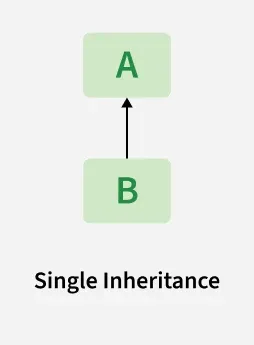

In [18]:
class Vehicle:
    def __init__(self, brand, price, transport_mode='Sea'):
        self.brand = brand
        self.transport_mode = transport_mode
        self.price = price

    def start_sound(self):
        print("starting vehicle")

class Car(Vehicle):
    def __init__(self, brand, price, transport_mode, num_wheels, car_type='SUV'):
        super().__init__(brand, price, transport_mode)
        self.num_wheels = num_wheels
        self.car_type = car_type

    @staticmethod
    def start_sound():
        print("Car starting")

        
    
Car1 = Car("Toyota", 20000, 'Land', 4)
print(Car1.start_sound())
print(Car1.__dict__)
        

Car starting

{'brand': 'Toyota', 'transport_mode': 'Land', 'price': 20000, 'num_wheels': 4, 'car_type': 'SUV'}




<hr>


The arguments accepted by the subclass `__init__` do not need to mirror the base class. The only strict requirement is that whatever you pass into `super().__init__(...)` must satisfy what the base class expects.

---

### Common Patterns

**1. Subclass Takes Fewer Arguments (Hardcoding / Defaulting Base Values)**
If the subclass already knows certain properties of the parent class, you don't need to ask the user for them:

```python
class Vehicle:
    def __init__(self, brand: str, price: float, transport_mode: str):
        self.brand = brand
        self.price = price
        self.transport_mode = transport_mode

class Boat(Vehicle):
    # Boat always travels on 'Water', so no need to ask the user for transport_mode
    def __init__(self, brand: str, price: float):
        super().__init__(brand, price, transport_mode="Water")

```

---

**2. Subclass Transforms Arguments**
A subclass can accept completely different parameters and compute what the parent needs:

```python
class Rectangle:
    def __init__(self, width: float, height: float):
        self.width = width
        self.height = height

class Square(Rectangle):
    # A square only needs a single side_length
    def __init__(self, side_length: float):
        super().__init__(width=side_length, height=side_length)

```

---

**3. Flexible Forwarding using `*args` and `**kwargs**`
If you want the subclass to accept arbitrary parent arguments without listing them explicitly:

```python
class CustomCar(Vehicle):
    def __init__(self, num_doors: int, *args, **kwargs):
        self.num_doors = num_doors
        # Forwards all other positional/keyword arguments directly to Vehicle
        super().__init__(*args, **kwargs)

# Instantiation
my_car = CustomCar(4, brand="Toyota", price=25000, transport_mode="Land")

```

---

* **`def __init__(self, ...)`** $\rightarrow$ Defines what the **caller/user** must supply when creating the subclass object.
* **`super().__init__(...)`** $\rightarrow$ Defines what the **parent class** needs to initialize its state properly.

---
Vehicle.__init__(self, brand, price)  # 'self' is required here!

If you accidentally write super().__init__(self, brand, price), Python will attempt to pass self twice, resulting in a:
TypeError: Vehicle.__init__() takes 3 positional arguments but 4 were given

In [19]:
print(help(Car))

Help on class Car in module __main__:

class Car(Vehicle)
 |  Car(brand, price, transport_mode, num_wheels, car_type='SUV')
 |
 |  Method resolution order:
 |      Car
 |      Vehicle
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __init__(self, brand, price, transport_mode, num_wheels, car_type='SUV')
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  ----------------------------------------------------------------------
 |  Static methods defined here:
 |
 |  start_sound()
 |
 |  ----------------------------------------------------------------------
 |  Data descriptors inherited from Vehicle:
 |
 |  __dict__
 |      dictionary for instance variables
 |
 |  __weakref__
 |      list of weak references to the object

None


In [21]:
print(Car.__mro__)

(<class '__main__.Car'>, <class '__main__.Vehicle'>, <class 'object'>)



---

super() doesn't mean "call my parent" — it means "call the next class in the MRO".

Single inheritance?
    └── Always use super().__init__() — cleaner, future proof

Multiple inheritance with related classes (diamond)?
    └── Always use super().__init__() + **kwargs — MRO handles order

Multiple inheritance with unrelated mixins?
    ├── super().__init__() if mixins are cooperative (they also call super)
    └── Direct calls if mixins are independent and unrelated to each other (A.__init__())

No instance state needed?
    └── Skip __init__ entirely

<h1> Mutliple Inheritance </h1>

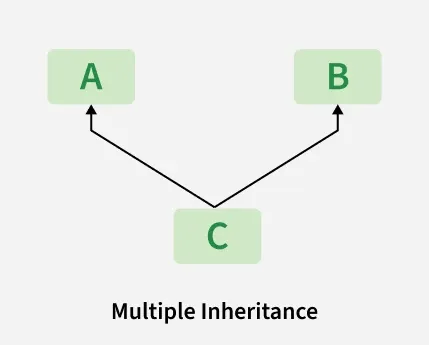

In [47]:
class A:
    attr_a = 'a'
    def hi_from_a(self):
        print("Hi from A")

class B:
    attr_b = 'b'
    def hi_from_b(self):
        print("Hi from B")

class C(A, B):
    def __init__(self):
        self.attr_c = self.attr_a + self.attr_b
    
    def hi(self):
        print(self.attr_c)


a1 = A()
# print(a1.__dict__) #instance dictionary so class variable and methods not shown
c1 = C()
c1.attr_a = "m"    #modifies the attr_a locally for the c1 instance
a1.attr_a = "n"    #modifies the class variable of A
c1.hi()            #attr_c was already formed in the init logic so no effect after setting the attr_a 
c1.hi_from_a()     
print(c1.attr_a)
print(a1.attr_a)
# print(A.__dict__)




ab
Hi from A
m
n


---
<h1>MultiLevel Inheritance</h1>

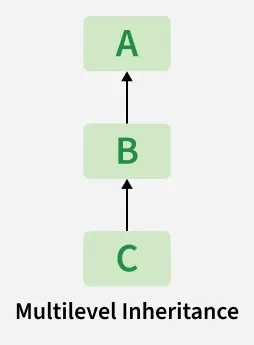